# Spotify Songs 2023 - Exploratory Data Analysis

## Research Question
Which audio features are most strongly associated with Spotify streaming success in 2023?

## Step 1 — Research Question and Model Type (LightGBM Approach)

### Research Question

The goal of this project is to understand and predict a song’s streaming success (`streams`) using multiple features, including audio characteristics (e.g., danceability, energy, valence), platform exposure (e.g., playlist and chart presence), and release information (e.g., year).

Instead of assuming a simple linear relationship between these variables and streaming success, we aim to explore whether the outcome is driven by nonlinear patterns, feature interactions, and threshold effects.

---

### Model Type

This is a **regression problem** because the target variable `streams` is continuous (a numeric quantity).

To model this relationship, we use a **gradient boosting tree-based model**, specifically:

- LightGBM Regressor

LightGBM is chosen because it can effectively capture complex nonlinear relationships and interactions between features. Unlike a single decision tree, LightGBM builds multiple trees sequentially, where each new tree focuses on correcting the errors made by previous ones. This results in stronger predictive performance and better generalization.

In addition, LightGBM provides feature importance scores, allowing us to interpret which variables contribute most to streaming success. This makes it suitable not only for prediction but also for understanding the underlying drivers of song popularity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from lightgbm import LGBMRegressor

df = pd.read_csv("spotify-2023.csv", encoding="latin1")

df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Step 2 — Data Inspection and Cleaning

Before building the LightGBM model, I first inspect the dataset to understand its structure, data types, and missing values. This step is important because machine learning models require clean and properly formatted input data.

In this dataset, the target variable `streams` should be numeric because it represents the number of Spotify streams. However, it may be read as an object due to formatting issues or non-numeric values. Therefore, I convert `streams` into a numeric variable and remove rows where the target value is missing.

This cleaning step ensures that the regression model can be trained correctly and that the target variable is suitable for prediction.

In [2]:
df.info()
df.isnull().sum()
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

df = df.dropna(subset=["streams"])

df["streams"].dtype

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null    str  
 1   artist(s)_name        953 non-null    str  
 2   artist_count          953 non-null    int64
 3   released_year         953 non-null    int64
 4   released_month        953 non-null    int64
 5   released_day          953 non-null    int64
 6   in_spotify_playlists  953 non-null    int64
 7   in_spotify_charts     953 non-null    int64
 8   streams               953 non-null    str  
 9   in_apple_playlists    953 non-null    int64
 10  in_apple_charts       953 non-null    int64
 11  in_deezer_playlists   953 non-null    str  
 12  in_deezer_charts      953 non-null    int64
 13  in_shazam_charts      903 non-null    str  
 14  bpm                   953 non-null    int64
 15  key                   858 non-null    str  
 16  mode               

dtype('float64')

## Step 3 — Transform Target Variable (log_streams)

The distribution of the target variable `streams` is highly right-skewed, meaning that a small number of songs have extremely large streaming counts while most songs have relatively lower values.

Using the raw `streams` variable in a regression model can lead to unstable predictions and make it difficult for the model to learn meaningful patterns. To address this issue, I apply a log transformation to the target variable.

By using `log_streams = log(1 + streams)`, we reduce the impact of extreme values and make the distribution more balanced. This transformation improves model stability, helps capture relative differences between songs, and often leads to better predictive performance.

Therefore, `log_streams` is used as the target variable in the LightGBM regression model.

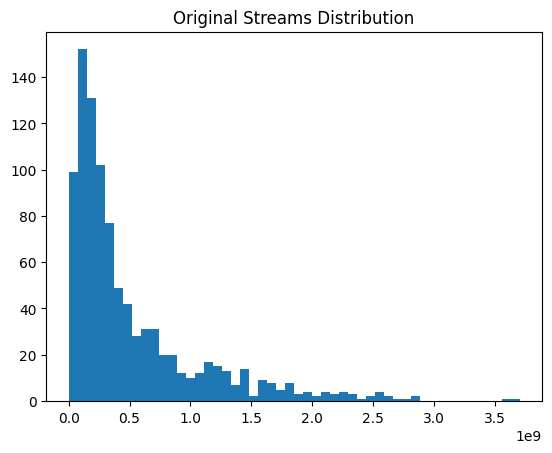

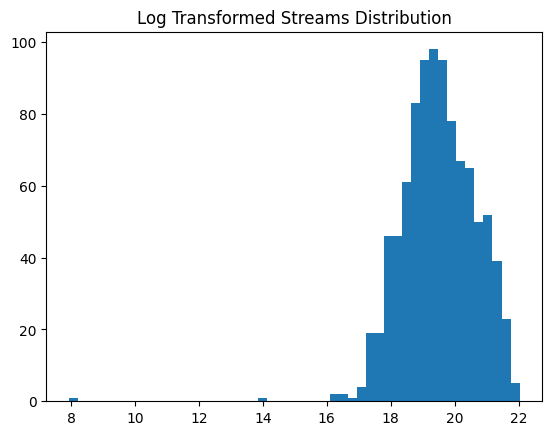

In [3]:
df["log_streams"] = np.log1p(df["streams"])
plt.hist(df["streams"], bins=50)
plt.title("Original Streams Distribution")
plt.show()
plt.hist(df["log_streams"], bins=50)
plt.title("Log Transformed Streams Distribution")
plt.show()

## Step 4 — Feature Selection

In this step, I select the input features (independent variables) that will be used to predict the target variable `log_streams`.

The selected features mainly include audio characteristics such as danceability, energy, valence, acousticness, and speechiness. These variables are directly related to how a song sounds and are likely to influence listener preferences and streaming behavior.

I exclude non-numeric columns such as track name and artist name because they cannot be directly used in the model without encoding. I also avoid including the original `streams` variable to prevent data leakage, since it is the source of the target variable.

By selecting relevant numeric features, I ensure that the model focuses on meaningful patterns while avoiding unnecessary complexity.

In [4]:
features = [
    "bpm",
    "danceability_%",
    "valence_%",
    "energy_%",
    "acousticness_%",
    "instrumentalness_%",
    "liveness_%",
    "speechiness_%"
]

X = df[features]
y = df["log_streams"]

## Step 5 — Train LightGBM Model

In this step, I train a LightGBM regression model to predict the target variable `log_streams` using the selected audio features.

The dataset is first split into a training set and a test set to evaluate the model’s generalization performance. The model is trained on the training set and later evaluated on unseen test data.

LightGBM is used because it builds trees sequentially, where each new tree focuses on correcting the errors made by previous trees. This allows the model to capture complex nonlinear relationships between audio features and streaming success.

To avoid overfitting, I use a controlled model configuration with a moderate number of trees and limited tree depth.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15
)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000549 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 761, number of used features: 8
[LightGBM] [Info] Start training from score 19.512190
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Step 6 — Model Evaluation

In this step, I evaluate the performance of the LightGBM model using the test dataset. This is important because it shows how well the model generalizes to unseen data.

I use three evaluation metrics:

- RMSE (Root Mean Squared Error): measures the average prediction error
- MAE (Mean Absolute Error): measures the average absolute difference
- R² (R-squared): measures how much variance in the target variable is explained by the model

These metrics together provide a comprehensive understanding of model performance.

In [6]:
y_pred = lgbm_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 1.055549708108047
MAE: 0.8498650621803471
R²: -0.08433108659739852


## Model Performance Interpretation

The model shows a negative R² value, indicating that the predictive performance is worse than a simple baseline model that predicts the mean.

This suggests that audio features alone have limited predictive power in explaining streaming success. While these features describe the musical characteristics of a song, they do not capture external factors such as marketing, playlist exposure, or artist popularity, which are likely more influential.

Therefore, the results imply that streaming success is not strongly determined by audio features alone, highlighting the importance of external and contextual factors.

## Step 7 — Feature Importance

In this step, I analyze the importance of each audio feature in the LightGBM model to understand which characteristics contribute most to predicting streaming success.

Although the overall predictive performance of the model is limited, feature importance still provides valuable insights into the relative influence of different audio features. It helps identify which musical attributes are more associated with higher streaming counts.

This step directly addresses the research question by highlighting the most influential audio features in the dataset.

Feature importance in LightGBM is defined based on how often and how effectively a feature is used to split the data across all trees in the model. Features that contribute more to reducing prediction error are assigned higher importance scores.

In [7]:
importance = lgbm_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,bpm,323
1,danceability_%,302
2,valence_%,253
4,acousticness_%,212
3,energy_%,177
6,liveness_%,136
7,speechiness_%,123
5,instrumentalness_%,20


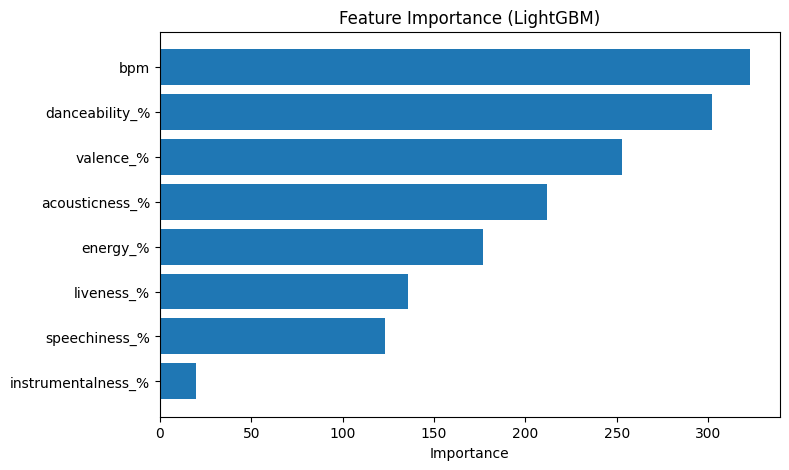

In [8]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance")
plt.show()

## Interpretation of Feature Importance

Although the overall predictive performance of the model is low, the feature importance results still provide useful insights into the relative contribution of different audio features.

The results suggest that features such as bpm and danceability are more frequently used by the model when making predictions, indicating that they contain relatively more information compared to other audio features.

However, the low R² value indicates that audio features as a whole have limited explanatory power for streaming success. Therefore, these results should be interpreted as relative importance within a weak feature set, rather than strong determinants of popularity.

## Step 8 — Platform Features and Streaming Success

After finding that audio features have limited explanatory power, I now examine whether platform-related features are more strongly associated with streaming success.

These features include variables such as playlist presence and chart rankings, which reflect a song’s exposure and visibility to listeners.

Unlike audio characteristics, platform features capture external factors such as promotion, recommendation systems, and audience reach. Therefore, they are expected to have a stronger relationship with streaming performance.

By building a model using only platform-related features, I can evaluate whether these variables provide higher explanatory power compared to audio features.

In [10]:
platform_features = [
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_deezer_playlists"
]

X_platform = df[platform_features].copy()
y = df["log_streams"]

for col in platform_features:
    X_platform[col] = pd.to_numeric(X_platform[col], errors="coerce")

X_platform = X_platform.dropna()
y = y.loc[X_platform.index]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_platform, y, test_size=0.2, random_state=42
)

model_p = LGBMRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    verbose=-1
)

model_p.fit(X_train_p, y_train_p)

y_pred_p = model_p.predict(X_test_p)

print("R²:", r2_score(y_test_p, y_pred_p))

R²: 0.3585439075512925


## Comparison Between Audio and Platform Features

The comparison between the two models shows a clear difference in explanatory power.

The model using only audio features produces a negative R², indicating that these features have very limited ability to explain streaming success. In contrast, the model using platform-related features achieves a significantly higher R² of approximately 0.36.

This result suggests that streaming success is much more strongly associated with platform exposure, such as playlist presence and chart rankings, rather than the intrinsic audio characteristics of a song.

Therefore, external factors related to visibility and promotion appear to play a more dominant role in determining a song’s popularity on Spotify.

## Step 9 — Combined Model (Audio + Platform Features)

In this step, I combine both audio features and platform-related features into a single model to evaluate their joint explanatory power.

This allows me to examine whether audio features still provide additional information once platform exposure is taken into account. If the model performance improves, it suggests that both types of features contribute to explaining streaming success.

By comparing this combined model with the previous models, I can better understand the relative importance and interaction between intrinsic musical characteristics and external exposure factors.

In [11]:
all_features = [
    "bpm",
    "danceability_%",
    "valence_%",
    "energy_%",
    "acousticness_%",
    "instrumentalness_%",
    "liveness_%",
    "speechiness_%",
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_deezer_playlists"
]

X_all = df[all_features].copy()
y = df["log_streams"]

for col in all_features:
    X_all[col] = pd.to_numeric(X_all[col], errors="coerce")

X_all = X_all.dropna()
y = y.loc[X_all.index]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

model_a = LGBMRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    verbose=-1
)

model_a.fit(X_train_a, y_train_a)

y_pred_a = model_a.predict(X_test_a)

from sklearn.metrics import r2_score

print("R² (All Features):", r2_score(y_test_a, y_pred_a))

R² (All Features): 0.3476242820148864


## Final Conclusion

This project examines the relationship between audio features, platform exposure, and streaming success on Spotify.

The results show that audio features alone have very limited explanatory power, as indicated by a negative R² value. In contrast, platform-related features significantly improve model performance, achieving an R² of approximately 0.36.

When combining both audio and platform features, the model does not show further improvement, suggesting that audio features provide little additional information beyond what is already captured by platform exposure.

These findings indicate that streaming success is primarily driven by external factors such as playlist placement and chart presence, rather than intrinsic musical characteristics. While audio features may influence listener preferences, they are not strong predictors of overall popularity in this dataset.

Overall, the analysis highlights the dominant role of exposure and distribution in determining a song’s success on streaming platforms.